# System rekomendacji win – NCF z cechami treściowymi











W tej wersji cechy treściowe trafiają **bezpośrednio do NCF** – sieć uczy się
łączyć preferencje użytkownika z opisem wina jednocześnie.


## 1. Importy

In [1]:
import ast
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import (
    normalize, MultiLabelBinarizer, MinMaxScaler, LabelEncoder
)
from scipy.sparse import csr_matrix, diags
import xgboost as xgb
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Używamy:', device)

Używamy: cuda


## 2. Wczytanie i podział danych (bez zmian)

In [2]:
df       = pd.read_csv('data/XWines_Slim_150K_ratings.csv')
df       = df[['UserID', 'WineID', 'Rating', 'Date']].copy()
wines_df = pd.read_csv('data/XWines_Slim_1K_wines.csv')

df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

split    = int(len(df) * 0.8)
train_df = df.iloc[:split].copy()
test_df  = df.iloc[split:].copy()

print(f'Trening: {len(train_df):,} ocen')
print(f'Test:    {len(test_df):,} ocen')

Trening: 120,000 ocen
Test:    30,000 ocen


## 3. Mapowanie ID na indeksy (bez zmian)

In [3]:
user2idx = {u: i for i, u in enumerate(train_df['UserID'].unique())}
wine2idx = {w: i for i, w in enumerate(train_df['WineID'].unique())}

num_users = len(user2idx)
num_wines = len(wine2idx)
print(f'Użytkownicy: {num_users:,}  |  Wina: {num_wines:,}')

train_df['user_idx'] = train_df['UserID'].map(user2idx)
train_df['wine_idx'] = train_df['WineID'].map(wine2idx)
test_df['user_idx']  = test_df['UserID'].map(user2idx)
test_df['wine_idx']  = test_df['WineID'].map(wine2idx)

mask    = test_df['user_idx'].notna() & test_df['wine_idx'].notna()
test_df = test_df[mask].copy()
test_df[['user_idx', 'wine_idx']]  = test_df[['user_idx', 'wine_idx']].astype(int)
train_df[['user_idx', 'wine_idx']] = train_df[['user_idx', 'wine_idx']].astype(int)

print(f'Test po cold-start: {len(test_df):,} ocen')

Użytkownicy: 10,357  |  Wina: 1,000
Test po cold-start: 28,200 ocen


## 4. Budowanie wektora cech treściowych wina (bez zmian)



In [4]:
def parse_list_col(col):
    return col.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

wines_df['Grapes']    = parse_list_col(wines_df['Grapes'])
wines_df['Harmonize'] = parse_list_col(wines_df['Harmonize'])

le_type    = LabelEncoder()
le_body    = LabelEncoder()
le_acidity = LabelEncoder()
le_country = LabelEncoder()

wines_df['Type_idx']    = le_type.fit_transform(wines_df['Type'].fillna('Unknown'))
wines_df['Body_idx']    = le_body.fit_transform(wines_df['Body'].fillna('Unknown'))
wines_df['Acidity_idx'] = le_acidity.fit_transform(wines_df['Acidity'].fillna('Unknown'))
wines_df['Country_idx'] = le_country.fit_transform(wines_df['Country'].fillna('Unknown'))

scaler_abv = MinMaxScaler()
wines_df['ABV_scaled'] = scaler_abv.fit_transform(
    wines_df[['ABV']].fillna(wines_df['ABV'].mean())
)

mlb_grapes = MultiLabelBinarizer(sparse_output=False)
grapes_enc = mlb_grapes.fit_transform(wines_df['Grapes'])

mlb_harm  = MultiLabelBinarizer(sparse_output=False)
harm_enc  = mlb_harm.fit_transform(wines_df['Harmonize'])

base_cols           = ['Type_idx', 'Body_idx', 'Acidity_idx', 'Country_idx', 'ABV_scaled']
content_base        = wines_df[base_cols].values.astype(float)
wine_content_matrix = np.hstack([content_base, grapes_enc, harm_enc]).astype(np.float32)

wine_feat_dim = wine_content_matrix.shape[1]
print(f'Wymiar wektora cech: {wine_feat_dim}')
print(f'  cechy bazowe: {content_base.shape[1]}  |  szczepy: {grapes_enc.shape[1]}  |  pairings: {harm_enc.shape[1]}')

zero_vec    = np.zeros(wine_feat_dim, dtype=np.float32)
wines_reset = wines_df.reset_index(drop=True)

wine_content_dict: dict = {}
for pos, row in wines_reset.iterrows():
    w_id = row['WineID']
    if w_id in wine2idx:
        wine_content_dict[wine2idx[w_id]] = wine_content_matrix[pos]

print(f'Zaindeksowano: {len(wine_content_dict)} / {len(wine2idx)} win')

Wymiar wektora cech: 239
  cechy bazowe: 5  |  szczepy: 188  |  pairings: 46
Zaindeksowano: 1000 / 1000 win


## 5. Metryki (bez zmian)

In [5]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def r2(y_true, y_pred):
    return float(r2_score(y_true, y_pred))

def precision_at_k(y_true, y_pred, k=10, threshold=4.0):
    top_k_idx = np.argsort(y_pred)[::-1][:k]
    return float(np.sum(y_true[top_k_idx] >= threshold) / k)

def recall_at_k(y_true, y_pred, k=10, threshold=4.0):
    top_k_idx    = np.argsort(y_pred)[::-1][:k]
    all_relevant = np.sum(y_true >= threshold)
    if all_relevant == 0:
        return 0.0
    return float(np.sum(y_true[top_k_idx] >= threshold) / all_relevant)

def ndcg_at_k(y_true, y_pred, k=10):
    def dcg(scores, k):
        s = np.array(scores, dtype=float)[:k]
        return np.sum(s / np.log2(np.arange(2, s.size + 2)))
    pred_order  = np.argsort(y_pred)[::-1][:k]
    ideal_order = np.argsort(y_true)[::-1][:k]
    ideal = dcg(y_true[ideal_order], k)
    return 0.0 if ideal == 0 else float(dcg(y_true[pred_order], k) / ideal)

def ranking_per_user(test_data, y_true_col, y_pred_col, k=10):
    p_list, r_list, n_list = [], [], []
    for uid, group in test_data.groupby('user_idx'):
        if len(group) < k:
            continue
        yt = group[y_true_col].values
        yp = group[y_pred_col].values
        p_list.append(precision_at_k(yt, yp, k))
        r_list.append(recall_at_k(yt, yp, k))
        n_list.append(ndcg_at_k(yt, yp, k))
    return {
        f'Precision@{k}': round(np.mean(p_list), 4) if p_list else float('nan'),
        f'Recall@{k}':    round(np.mean(r_list), 4) if r_list else float('nan'),
        f'NDCG@{k}':      round(np.mean(n_list), 4) if n_list else float('nan'),
    }

print('Metryki gotowe.')

Metryki gotowe.


## 6. RP3β (bez zmian)

In [6]:
class RP3Beta:
    def __init__(self, beta=0.3):
        self.beta = beta

    def fit(self, df):
        self.users    = df['UserID'].unique()
        self.items    = df['WineID'].unique()
        self.user2idx = {u: i for i, u in enumerate(self.users)}
        self.item2idx = {w: j for j, w in enumerate(self.items)}
        rows = df['UserID'].map(self.user2idx).values
        cols = df['WineID'].map(self.item2idx).values
        self.R = csr_matrix(
            (df['Rating'].values.astype(float), (rows, cols)),
            shape=(len(self.users), len(self.items))
        )
        P_iu = normalize(self.R.T, norm='l1', axis=1)
        P_ui = normalize(self.R,   norm='l1', axis=1)
        S    = P_iu @ P_ui
        popularity = np.array(self.R.sum(axis=0)).flatten()
        penalty    = np.where(popularity > 0,
                              np.power(popularity, self.beta, where=popularity > 0), 1.0)
        self.S = S @ diags(1.0 / penalty)
        return self

    def get_scores(self, user_id, candidate_wines=None):
        u = self.user2idx.get(user_id)
        if u is None:
            return None, None
        scores = (self.R[u] @ self.S).toarray().flatten()
        if candidate_wines is not None:
            mask   = np.array([w in self.item2idx for w in candidate_wines])
            scores = np.array([scores[self.item2idx[w]]
                               for w in candidate_wines if w in self.item2idx])
            return scores, mask
        return scores, None


print('Trening RP3β...')
rp3 = RP3Beta(beta=0.3).fit(train_df)
print('Gotowe!')

Trening RP3β...
Gotowe!


In [7]:
precisions_5, recalls_5, ndcgs_5   = [], [], []
precisions_10, recalls_10, ndcgs_10 = [], [], []

for user_id, group in test_df.groupby('UserID'):
    if user_id not in rp3.user2idx:
        continue
    y_true   = group['Rating'].values
    wine_ids = group['WineID'].values
    scores, mask = rp3.get_scores(user_id, candidate_wines=wine_ids)
    if scores is None:
        continue
    y_true_f = y_true[mask]
    if len(scores) >= 5:
        precisions_5.append(precision_at_k(y_true_f, scores, k=5))
        recalls_5.append(recall_at_k(y_true_f, scores, k=5))
        ndcgs_5.append(ndcg_at_k(y_true_f, scores, k=5))
    if len(scores) >= 10:
        precisions_10.append(precision_at_k(y_true_f, scores, k=10))
        recalls_10.append(recall_at_k(y_true_f, scores, k=10))
        ndcgs_10.append(ndcg_at_k(y_true_f, scores, k=10))

metrics_rp3 = {
    'Model': 'RP3β',
    'RMSE': float('nan'), 'MAE': float('nan'), 'R2': float('nan'),
    'Precision@5':  round(np.mean(precisions_5),  4),
    'Recall@5':     round(np.mean(recalls_5),     4),
    'NDCG@5':       round(np.mean(ndcgs_5),       4),
    'Precision@10': round(np.mean(precisions_10), 4),
    'Recall@10':    round(np.mean(recalls_10),    4),
    'NDCG@10':      round(np.mean(ndcgs_10),      4),
}
display(pd.DataFrame([metrics_rp3]))

,Model,RMSE,MAE,R2,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10
0,RP3β,NaN,NaN,NaN,0.7134,0.7693,0.9547,0.7008,0.8697,0.9571


## 7. ⭐ NOWOŚĆ: Przygotowanie DataLoaderów z cechami treściowymi

To jest pierwsza kluczowa zmiana względem poprzedniego notebooka.

Poprzednio DataLoader dostarczał tylko trzy rzeczy do sieci:
```python
TensorDataset(X_user, X_wine, y_rating)
#              ↑        ↑        ↑
#           user_idx  wine_idx  ocena
```

Teraz dodajemy czwarty element – wektor cech treściowych wina:
```python
TensorDataset(X_user, X_wine, X_content, y_rating)
#              ↑        ↑        ↑            ↑
#           user_idx  wine_idx  cechy_wina   ocena
#                               (N liczb)
```

Dla każdego wiersza w train_df/test_df pobieramy wektor cech
odpowiadającego wina z `wine_content_dict`.

In [8]:
# ── Budowanie macierzy content dla każdego wiersza w zbiorze ──────────────
# Dla każdej oceny w train_df / test_df pobieramy wektor cech wina
# z wine_content_dict. Wynik to macierz kształtu (liczba_ocen, wine_feat_dim).

def build_content_matrix(df_split, content_dict, zero_vec):
    """
    Dla każdego wiersza w df_split zwraca wektor cech treściowych wina.
    Jeśli wino nie ma opisu → wektor zerowy.
    """
    rows = [content_dict.get(w_idx, zero_vec)
            for w_idx in df_split['wine_idx'].values]
    return np.vstack(rows).astype(np.float32)  # (N_próbek, wine_feat_dim)


print('Budowanie macierzy content dla treningu i testu...')
content_train_np = build_content_matrix(train_df, wine_content_dict, zero_vec)
content_test_np  = build_content_matrix(test_df,  wine_content_dict, zero_vec)

print(f'content_train: {content_train_np.shape}  ← (próbki treningowe × {wine_feat_dim} cech)')
print(f'content_test:  {content_test_np.shape}')

Budowanie macierzy content dla treningu i testu...
content_train: (120000, 239)  ← (próbki treningowe × 239 cech)
content_test:  (28200, 239)


In [9]:
# ── Tensory PyTorch ───────────────────────────────────────────────────────

X_user_train    = torch.tensor(train_df['user_idx'].values, dtype=torch.long)
X_wine_train    = torch.tensor(train_df['wine_idx'].values, dtype=torch.long)
X_content_train = torch.tensor(content_train_np,            dtype=torch.float32)  # ← NOWE
y_train_t       = torch.tensor(train_df['Rating'].values,   dtype=torch.float32)

X_user_test     = torch.tensor(test_df['user_idx'].values,  dtype=torch.long)
X_wine_test     = torch.tensor(test_df['wine_idx'].values,  dtype=torch.long)
X_content_test  = torch.tensor(content_test_np,             dtype=torch.float32)  # ← NOWE
y_test_t        = torch.tensor(test_df['Rating'].values,    dtype=torch.float32)

BATCH = 2048

# TensorDataset teraz ma 4 elementy zamiast 3 – dodaliśmy X_content
train_loader = DataLoader(
    TensorDataset(X_user_train, X_wine_train, X_content_train, y_train_t),
    batch_size=BATCH, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(X_user_test, X_wine_test, X_content_test, y_test_t),
    batch_size=BATCH
)

print(f'Batchy treningowych: {len(train_loader)}')
print(f'Batchy testowych:    {len(test_loader)}')
print(f'Każdy batch: (users, wines, content, ratings)')
print(f'  content ma kształt (batch_size={BATCH}, {wine_feat_dim})')

Batchy treningowych: 59
Batchy testowych:    14
Każdy batch: (users, wines, content, ratings)
  content ma kształt (batch_size=2048, 239)


## 8. ⭐ NOWOŚĆ: NCF content-aware

To jest druga kluczowa zmiana – sama architektura sieci.

### Co się zmienia w klasie NCF?

**Stary NCF:**
```python
class NCF(nn.Module):
    def __init__(self, n_users, n_wines, emb_dim=50):
        self.fc = nn.Linear(emb_dim * 2, 128)   # wejście: 100

    def forward(self, users, wines):
        x = torch.cat([self.user_emb(users),
                        self.wine_emb(wines)], dim=1)
        return self.fc(x)   # x ma 100 wymiarów
```

**Nowy NCF (content-aware):**
```python
class NCF(nn.Module):
    def __init__(self, n_users, n_wines, emb_dim=50, content_dim=N):
        self.fc = nn.Linear(emb_dim * 2 + content_dim, 128)  # wejście: 100+N

    def forward(self, users, wines, content):   # ← nowy argument
        x = torch.cat([self.user_emb(users),
                        self.wine_emb(wines),
                        content], dim=1)        # ← doklejamy content
        return self.fc(x)   # x ma 100+N wymiarów
```

Trzy konkretne zmiany:
1. Konstruktor przyjmuje `content_dim` – żeby wiedzieć jak duże jest wejście MLP
2. `forward()` przyjmuje `content` – tensor z cechami treściowymi
3. `torch.cat(...)` łączy trzy tensory zamiast dwóch

Sieć ContentBN to dodatkowa warstwa normalizacji dla content features
– cechy treściowe mają różne skale (0/1 dla one-hot, [0,1] dla ABV),
normalizacja pomaga sieci uczyć się szybciej.

In [ ]:
class NCFContent(nn.Module):
    """
    NCF z cechami treściowymi wina.

    Wejście do MLP:
        [user_emb (emb_dim) | wine_emb (emb_dim) | content (content_dim)]
         ← nauczone          ← nauczone            ← z wines.csv (NOWOŚĆ)
    """

    def __init__(self, n_users, n_wines, emb_dim=32, content_dim=0):
        super().__init__()

        # Tabele embeddingów – bez zmian
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.wine_emb = nn.Embedding(n_wines, emb_dim)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.wine_emb.weight, std=0.01)

        # ── NOWOŚĆ: normalizacja cech treściowych przed wejściem do MLP ──
        # Content features mają różne skale (0/1, [0,1], int).
        # BatchNorm wyrównuje je tak żeby sieć mogła je łatwo porównywać.
        self.content_bn = nn.BatchNorm1d(content_dim) if content_dim > 0 else None

        # ── NOWOŚĆ: wejście MLP jest teraz szersze o content_dim ──────────
        # Stare:  emb_dim * 2            = 100
        # Nowe:   emb_dim * 2 + content_dim = 100 + N
        input_dim = emb_dim * 2 + content_dim

        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),   # szersza pierwsza warstwa – więcej cech na wejściu
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, users, wines, content):  # ← NOWOŚĆ: argument content
        u_emb = self.user_emb(users)   # (batch, 50)
        w_emb = self.wine_emb(wines)   # (batch, 50)

        # ── NOWOŚĆ: normalizujemy i dołączamy cechy treściowe ─────────────
        if self.content_bn is not None:
            content = self.content_bn(content)  # wyrównanie skal

        # Łączymy trzy tensory w jeden wiersz
        x = torch.cat([u_emb, w_emb, content], dim=1)  # (batch, 100+N)
        # ─────────────────────────────────────────────────────────────────

        return self.fc(x)   # (batch, 1)


# Tworzymy model – przekazujemy wine_feat_dim żeby MLP wiedziało jak szerokie wejście
model_ncf = NCFContent(
    n_users=num_users,
    n_wines=num_wines,
    emb_dim=50,
    content_dim=wine_feat_dim   # featury wina
).to(device)

# Sprawdzamy wymiary
total_params = sum(p.numel() for p in model_ncf.parameters() if p.requires_grad)
print(f'Wymiar wejścia MLP: 50 + 50 + {wine_feat_dim} = {100 + wine_feat_dim}')
print(f'Łączna liczba parametrów: {total_params:,}')

Wymiar wejścia MLP: 50 + 50 + 239 = 339
Łączna liczba parametrów: 697,097


## 9. ⭐ Trening NCF content-aware

Pętla treningowa wygląda prawie tak samo jak poprzednio.
Jedyna zmiana: batch teraz ma 4 elementy zamiast 3,
i przekazujemy `content` do `model_ncf(users, wines, content)`.

Zaznaczone są wszystkie miejsca gdzie pojawia się `content`.

In [11]:
optimizer = optim.Adam(model_ncf.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
criterion = nn.MSELoss()

best_val_loss  = float('inf')

patience_count = 0
PATIENCE       = 5
train_losses, val_losses = [], []

print('Trening NCFContent (max 20 epok)...')
for epoch in range(20):

    # ── Faza treningu ─────────────────────────────────────────────────────
    model_ncf.train()
    total_train = 0
    for users, wines, content, ratings in train_loader:  # ← NOWOŚĆ: content w pętli
        users   = users.to(device)
        wines   = wines.to(device)
        content = content.to(device)   # ← NOWOŚĆ: content na GPU/CPU
        ratings = ratings.to(device)

        optimizer.zero_grad()
        preds = model_ncf(users, wines, content).squeeze()  # ← NOWOŚĆ: 3 argumenty
        loss  = criterion(preds, ratings)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ncf.parameters(), 1.0)
        optimizer.step()
        total_train += loss.item()
    avg_train = total_train / len(train_loader)

    # ── Faza walidacji ────────────────────────────────────────────────────
    model_ncf.eval()
    total_val = 0
    with torch.no_grad():
        for users, wines, content, ratings in test_loader:  # ← NOWOŚĆ: content
            users   = users.to(device)
            wines   = wines.to(device)
            content = content.to(device)   # ← NOWOŚĆ
            ratings = ratings.to(device)
            preds   = model_ncf(users, wines, content).squeeze()  # ← NOWOŚĆ
            total_val += criterion(preds, ratings).item()
    avg_val = total_val / len(test_loader)

    scheduler.step(avg_val)
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print(f'  Epoka {epoch+1:2d}: train={avg_train:.4f}  val={avg_val:.4f}', end='')

    if avg_val < best_val_loss:
        best_val_loss  = avg_val
        patience_count = 0
        torch.save(model_ncf.state_dict(), 'best_ncf_content.pt')
        print(' ← najlepszy!', end='')
    else:
        patience_count += 1
    print()

    if patience_count >= PATIENCE:
        print(f'  Early stopping po epoce {epoch+1}')
        break

model_ncf.load_state_dict(torch.load('best_ncf_content.pt'))
print(f'\nNajlepszy val loss: {best_val_loss:.4f}')

Trening NCFContent (max 20 epok)...
  Epoka  1: train=2.4036  val=0.3826 ← najlepszy!
  Epoka  2: train=0.3814  val=0.2796 ← najlepszy!
  Epoka  3: train=0.3336  val=0.3108
  Epoka  4: train=0.3170  val=0.2821
  Epoka  5: train=0.3025  val=0.2903
  Epoka  6: train=0.2800  val=0.2647 ← najlepszy!
  Epoka  7: train=0.2695  val=0.2423 ← najlepszy!
  Epoka  8: train=0.2636  val=0.2604
  Epoka  9: train=0.2556  val=0.2397 ← najlepszy!
  Epoka 10: train=0.2500  val=0.2382 ← najlepszy!
  Epoka 11: train=0.2455  val=0.2904
  Epoka 12: train=0.2428  val=0.2340 ← najlepszy!
  Epoka 13: train=0.2373  val=0.2366
  Epoka 14: train=0.2328  val=0.2510
  Epoka 15: train=0.2311  val=0.2368
  Epoka 16: train=0.2215  val=0.2373
  Epoka 17: train=0.2190  val=0.2487
  Early stopping po epoce 17

Najlepszy val loss: 0.2340


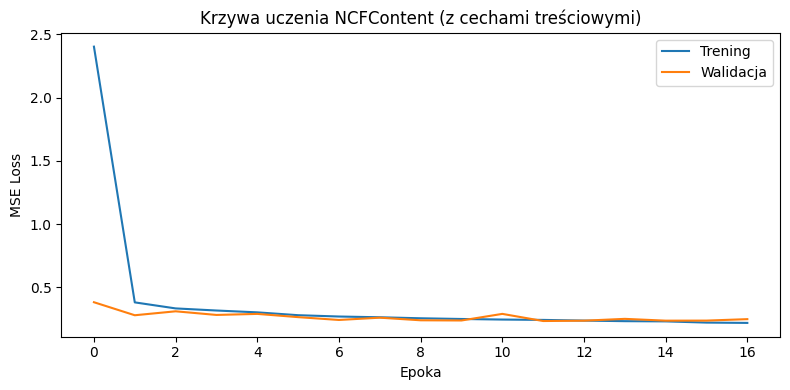

Wyniki NCFContent:


,Model,RMSE,MAE,R2,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10
0,NCFContent (emb + content),0.4835,0.359,0.2952,0.773,0.8323,0.9816,0.7489,0.9224,0.9846


In [12]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Trening')
plt.plot(val_losses,   label='Walidacja')
plt.xlabel('Epoka'); plt.ylabel('MSE Loss')
plt.title('Krzywa uczenia NCFContent (z cechami treściowymi)')
plt.legend(); plt.tight_layout(); plt.show()

# ── Ewaluacja NCFContent ──────────────────────────────────────────────────
model_ncf.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for users, wines, content, ratings in test_loader:   # ← NOWOŚĆ: content
        preds = model_ncf(
            users.to(device),
            wines.to(device),
            content.to(device)   # ← NOWOŚĆ
        ).squeeze().cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(ratings.numpy())

preds_ncf = np.array(all_preds)
trues_ncf = np.array(all_true)
test_df['pred_ncf'] = preds_ncf

metrics_ncf = {
    'Model': 'NCFContent (emb + content)',
    'RMSE':  round(rmse(trues_ncf, preds_ncf), 4),
    'MAE':   round(mae(trues_ncf,  preds_ncf), 4),
    'R2':    round(r2(trues_ncf,   preds_ncf), 4),
    **ranking_per_user(test_df, 'Rating', 'pred_ncf', k=5),
    **ranking_per_user(test_df, 'Rating', 'pred_ncf', k=10),
}

print('Wyniki NCFContent:')
display(pd.DataFrame([metrics_ncf]))

## 10. XGBoost / RF – trzy warianty

### Wariant A – raw (baseline, bez zmian)
Tylko `[user_idx, wine_idx]` – bez embeddingów, bez content.

### Wariant B – NCFContent embeddingi
Wyciągamy embeddingi z nowego NCF.
**Uwaga:** funkcja `get_embeddings` musi teraz przekazywać `content` do `forward()`.

### Wariant C – NCFContent embeddingi + content (ponownie dołączony)
Dołączamy content jeszcze raz "z zewnątrz".
NCF widział go wewnętrznie podczas treningu – ale XGBoost może
korzystać z tych samych surowych cech na swój sposób (inne drzewa decyzyjne).

In [13]:
# ════════════════════════════════════════════════════════════
# WARIANT A: Surowe ID (baseline)
# ════════════════════════════════════════════════════════════

X_train_raw = train_df[['user_idx', 'wine_idx']].values
y_train_raw = train_df['Rating'].values
X_test_raw  = test_df[['user_idx', 'wine_idx']].values
y_test_raw  = test_df['Rating'].values

print('Trening XGBoost (raw)...')
model_xgb_raw = xgb.XGBRegressor(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu', verbosity=0,
)
model_xgb_raw.fit(X_train_raw, y_train_raw)
preds_xgb_raw = model_xgb_raw.predict(X_test_raw)
test_df['pred_xgb_raw'] = preds_xgb_raw

metrics_xgb_raw = {
    'Model': 'XGBoost (raw)',
    'RMSE':  round(rmse(y_test_raw, preds_xgb_raw), 4),
    'MAE':   round(mae(y_test_raw,  preds_xgb_raw), 4),
    'R2':    round(r2(y_test_raw,   preds_xgb_raw), 4),
    **ranking_per_user(test_df, 'Rating', 'pred_xgb_raw', k=5),
    **ranking_per_user(test_df, 'Rating', 'pred_xgb_raw', k=10),
}

print('Trening Random Forest (raw)...')
model_rf_raw = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
model_rf_raw.fit(X_train_raw, y_train_raw)
preds_rf_raw = model_rf_raw.predict(X_test_raw)
test_df['pred_rf_raw'] = preds_rf_raw

metrics_rf_raw = {
    'Model': 'Random Forest (raw)',
    'RMSE':  round(rmse(y_test_raw, preds_rf_raw), 4),
    'MAE':   round(mae(y_test_raw,  preds_rf_raw), 4),
    'R2':    round(r2(y_test_raw,   preds_rf_raw), 4),
    **ranking_per_user(test_df, 'Rating', 'pred_rf_raw', k=5),
    **ranking_per_user(test_df, 'Rating', 'pred_rf_raw', k=10),
}

print('Wariant A gotowy.')
display(pd.DataFrame([metrics_xgb_raw, metrics_rf_raw]))

Trening XGBoost (raw)...
Trening Random Forest (raw)...
Wariant A gotowy.


,Model,RMSE,MAE,R2,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10
0,XGBoost (raw),0.5208,0.4009,0.1822,0.7452,0.8015,0.9720,0.7282,0.8996,0.9770
1,Random Forest (raw),0.5235,0.4059,0.1736,0.7428,0.7983,0.9715,0.7215,0.8902,0.9764


In [14]:
# ════════════════════════════════════════════════════════════
# WARIANT B: Embeddingi z NCFContent  (100 cech)
# ════════════════════════════════════════════════════════════
#
# ZMIANA vs poprzedniej wersji:
# Funkcja musi teraz przekazać content do model.forward().
# Batch ma 4 elementy: (users, wines, content, ratings).

def get_embeddings_ncf_content(model, loader, device):
    """
    Wyciąga [user_emb | wine_emb] z NCFContent.
    Content jest przekazywany do forward() (wymagane przez architekturę),
    ale nie jest włączony do zwracanego wektora cech.
    Wyjście: (N_próbek, 100)
    """
    model.eval()
    X_list, y_list = [], []
    with torch.no_grad():
        for users, wines, content, ratings in loader:   # ← 4 elementy
            u_emb = model.user_emb(users.to(device)).cpu().numpy()   # (batch, 50)
            w_emb = model.wine_emb(wines.to(device)).cpu().numpy()   # (batch, 50)
            # content jest wymagane przez forward() ale tu go nie dołączamy
            # – chcemy zobaczyć jak same embeddingi radzą sobie bez content
            X_list.append(np.hstack([u_emb, w_emb]))
            y_list.append(ratings.numpy())
    return np.concatenate(X_list), np.concatenate(y_list)


print('Ekstrakcja embeddingów z NCFContent (wariant B)...')
X_train_emb, y_train_emb = get_embeddings_ncf_content(model_ncf, train_loader, device)
X_test_emb,  y_test_emb  = get_embeddings_ncf_content(model_ncf, test_loader,  device)
print(f'Kształt X_train: {X_train_emb.shape}  ← 100 cech (tylko embeddingi)')

print('\nTrening XGBoost (NCFContent emb)...')
model_xgb_emb = xgb.XGBRegressor(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu', verbosity=0,
)
model_xgb_emb.fit(X_train_emb, y_train_emb)
preds_xgb_emb = model_xgb_emb.predict(X_test_emb)
test_df['pred_xgb_emb'] = preds_xgb_emb

metrics_xgb_emb = {
    'Model': 'XGBoost (NCFContent emb)',
    'RMSE':  round(rmse(y_test_emb, preds_xgb_emb), 4),
    'MAE':   round(mae(y_test_emb,  preds_xgb_emb), 4),
    'R2':    round(r2(y_test_emb,   preds_xgb_emb), 4),
    **ranking_per_user(test_df, 'Rating', 'pred_xgb_emb', k=5),
    **ranking_per_user(test_df, 'Rating', 'pred_xgb_emb', k=10),
}

print('Trening Random Forest (NCFContent emb)...')
model_rf_emb = RandomForestRegressor(
    n_estimators=100, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=42
)
model_rf_emb.fit(X_train_emb, y_train_emb)
preds_rf_emb = model_rf_emb.predict(X_test_emb)
test_df['pred_rf_emb'] = preds_rf_emb

metrics_rf_emb = {
    'Model': 'Random Forest (NCFContent emb)',
    'RMSE':  round(rmse(y_test_emb, preds_rf_emb), 4),
    'MAE':   round(mae(y_test_emb,  preds_rf_emb), 4),
    'R2':    round(r2(y_test_emb,   preds_rf_emb), 4),
    **ranking_per_user(test_df, 'Rating', 'pred_rf_emb', k=5),
    **ranking_per_user(test_df, 'Rating', 'pred_rf_emb', k=10),
}

print('\nWariant B gotowy.')
display(pd.DataFrame([metrics_xgb_emb, metrics_rf_emb]))

Ekstrakcja embeddingów z NCFContent (wariant B)...
Kształt X_train: (120000, 100)  ← 100 cech (tylko embeddingi)

Trening XGBoost (NCFContent emb)...
Trening Random Forest (NCFContent emb)...

Wariant B gotowy.


,Model,RMSE,MAE,R2,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10
0,XGBoost (NCFContent emb),0.4601,0.3436,0.3617,0.7696,0.8287,0.9813,0.7477,0.9208,0.9850
1,Random Forest (NCFContent emb),0.4621,0.3437,0.3560,0.7713,0.8299,0.9815,0.7441,0.9163,0.9846


In [15]:
# ════════════════════════════════════════════════════════════
# WARIANT C ⭐: NCFContent emb + content dołączony ponownie
# ════════════════════════════════════════════════════════════
#
# Dlaczego dołączamy content jeszcze raz?
# NCF używał content wewnętrznie (przez MLP) – nauczyło się pewnej
# reprezentacji. XGBoost dostaje te same surowe cechy i może odkryć
# inne wzorce niż sieć neuronowa (np. inne progi decyzyjne).
#
# To tzw. "feature stacking" – dwa modele patrzą na te same dane,
# ale z różnej perspektywy.

def get_embeddings_with_content(model, loader, device, content_dict, feat_dim, zero_vec):
    """
    Zwraca [user_emb | wine_emb | wine_content] dla każdej próbki.
    Wyjście: (N_próbek, 100 + wine_feat_dim)

    UWAGA: content w DataLoaderze to content PER PRÓBKA (z treningu/testu).
    Tutaj pobieramy ten sam content z wine_content_dict – efekt jest identyczny,
    ale kod jest czytelniejszy i niezależny od kolejności próbek w batchu.
    """
    model.eval()
    X_list, y_list = [], []
    with torch.no_grad():
        for users, wines, content, ratings in loader:   # ← 4 elementy
            u_emb = model.user_emb(users.to(device)).cpu().numpy()   # (batch, 50)
            w_emb = model.wine_emb(wines.to(device)).cpu().numpy()   # (batch, 50)
            # Pobieramy content z wine_content_dict (zamiast z loadera)
            w_idxs   = wines.numpy()
            content_np = np.vstack([content_dict.get(i, zero_vec) for i in w_idxs])
            X_list.append(np.hstack([u_emb, w_emb, content_np]))     # (batch, 100+N)
            y_list.append(ratings.numpy())
    return np.concatenate(X_list), np.concatenate(y_list)


print('Ekstrakcja cech pełnych (wariant C)...')
X_train_hyb, y_train_hyb = get_embeddings_with_content(
    model_ncf, train_loader, device, wine_content_dict, wine_feat_dim, zero_vec
)
X_test_hyb, y_test_hyb = get_embeddings_with_content(
    model_ncf, test_loader, device, wine_content_dict, wine_feat_dim, zero_vec
)
print(f'Kształt X_train: {X_train_hyb.shape}')
print(f'  = 50 user_emb + 50 wine_emb + {wine_feat_dim} content = {X_train_hyb.shape[1]} cech')

print('\nTrening XGBoost (hybrid)...')
model_xgb_hyb = xgb.XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu', verbosity=0,
)
model_xgb_hyb.fit(X_train_hyb, y_train_hyb,
                  eval_set=[(X_test_hyb, y_test_hyb)], verbose=False)
preds_xgb_hyb = model_xgb_hyb.predict(X_test_hyb)
test_df['pred_xgb_hyb'] = preds_xgb_hyb

metrics_xgb_hyb = {
    'Model': 'XGBoost (NCFContent + content)',
    'RMSE':  round(rmse(y_test_hyb, preds_xgb_hyb), 4),
    'MAE':   round(mae(y_test_hyb,  preds_xgb_hyb), 4),
    'R2':    round(r2(y_test_hyb,   preds_xgb_hyb), 4),
    **ranking_per_user(test_df, 'Rating', 'pred_xgb_hyb', k=5),
    **ranking_per_user(test_df, 'Rating', 'pred_xgb_hyb', k=10),
}

print('Trening Random Forest (hybrid)...')
model_rf_hyb = RandomForestRegressor(
    n_estimators=150, max_depth=20, min_samples_leaf=3, n_jobs=-1, random_state=42
)
model_rf_hyb.fit(X_train_hyb, y_train_hyb)
preds_rf_hyb = model_rf_hyb.predict(X_test_hyb)
test_df['pred_rf_hyb'] = preds_rf_hyb

metrics_rf_hyb = {
    'Model': 'Random Forest (NCFContent + content)',
    'RMSE':  round(rmse(y_test_hyb, preds_rf_hyb), 4),
    'MAE':   round(mae(y_test_hyb,  preds_rf_hyb), 4),
    'R2':    round(r2(y_test_hyb,   preds_rf_hyb), 4),
    **ranking_per_user(test_df, 'Rating', 'pred_rf_hyb', k=5),
    **ranking_per_user(test_df, 'Rating', 'pred_rf_hyb', k=10),
}

print('\nWariant C gotowy.')
display(pd.DataFrame([metrics_xgb_hyb, metrics_rf_hyb]))

Ekstrakcja cech pełnych (wariant C)...
Kształt X_train: (120000, 339)
  = 50 user_emb + 50 wine_emb + 239 content = 339 cech

Trening XGBoost (hybrid)...
Trening Random Forest (hybrid)...

Wariant C gotowy.


,Model,RMSE,MAE,R2,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10
0,XGBoost (NCFContent + content),0.4582,0.3420,0.3670,0.7720,0.8315,0.9823,0.7472,0.9205,0.9857
1,Random Forest (NCFContent + content),0.4638,0.3444,0.3514,0.7713,0.8303,0.9814,0.7466,0.9207,0.9850


## 11. Zestawienie wszystkich modeli

In [16]:
all_results = [
    metrics_xgb_raw,
    metrics_rf_raw,
    metrics_ncf,          # NCFContent (sieć z cechami treściowymi)
    metrics_xgb_emb,      # XGB na embeddingach z NCFContent
    metrics_rf_emb,
    metrics_xgb_hyb,      # XGB na emb + content
    metrics_rf_hyb,
    metrics_rp3,
]

COLS = [
    'Model', 'RMSE', 'MAE', 'R2',
    'Precision@5', 'Recall@5', 'NDCG@5',
    'Precision@10', 'Recall@10', 'NDCG@10',
]

results_df = pd.DataFrame(all_results, columns=COLS)
display(results_df.sort_values('NDCG@10', ascending=False, na_position='last'))

,Model,RMSE,MAE,R2,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10
5,XGBoost (NCFContent + content),0.4582,0.3420,0.3670,0.7720,0.8315,0.9823,0.7472,0.9205,0.9857
3,XGBoost (NCFContent emb),0.4601,0.3436,0.3617,0.7696,0.8287,0.9813,0.7477,0.9208,0.9850
6,Random Forest (NCFContent + content),0.4638,0.3444,0.3514,0.7713,0.8303,0.9814,0.7466,0.9207,0.9850
2,NCFContent (emb + content),0.4835,0.3590,0.2952,0.7730,0.8323,0.9816,0.7489,0.9224,0.9846
4,Random Forest (NCFContent emb),0.4621,0.3437,0.3560,0.7713,0.8299,0.9815,0.7441,0.9163,0.9846
0,XGBoost (raw),0.5208,0.4009,0.1822,0.7452,0.8015,0.9720,0.7282,0.8996,0.9770
1,Random Forest (raw),0.5235,0.4059,0.1736,0.7428,0.7983,0.9715,0.7215,0.8902,0.9764
7,RP3β,NaN,NaN,NaN,0.7134,0.7693,0.9547,0.7008,0.8697,0.9571


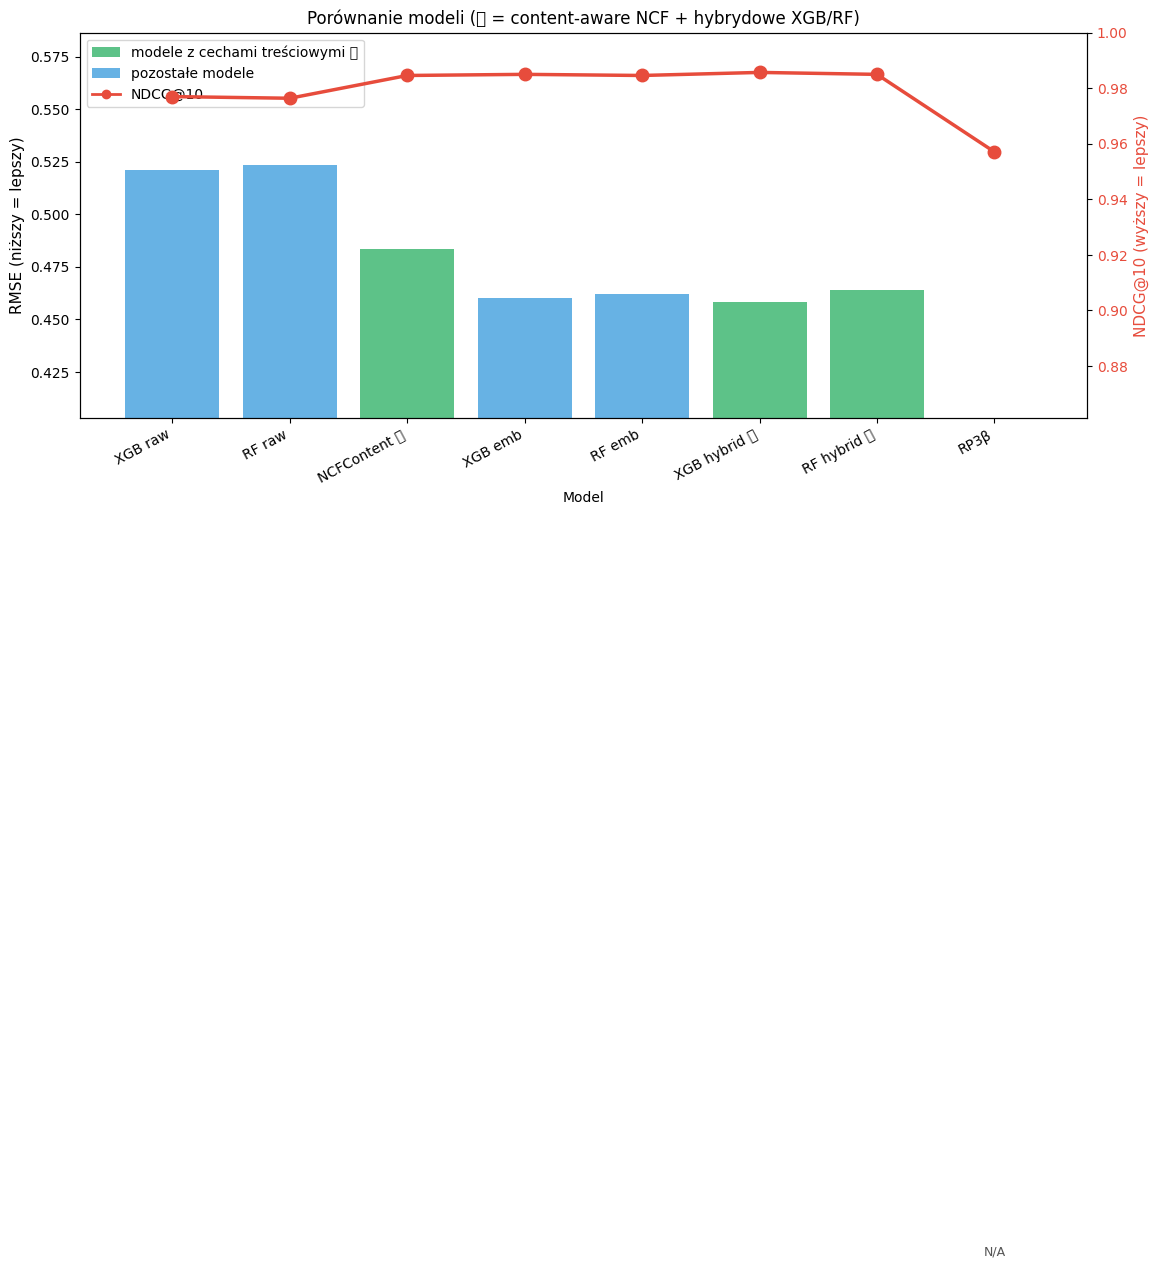

In [17]:
plot_df = results_df.copy()
short_names = {
    'XGBoost (raw)':                       'XGB raw',
    'Random Forest (raw)':                 'RF raw',
    'NCFContent (emb + content)':          'NCFContent ⭐',
    'XGBoost (NCFContent emb)':            'XGB emb',
    'Random Forest (NCFContent emb)':      'RF emb',
    'XGBoost (NCFContent + content)':      'XGB hybrid ⭐',
    'Random Forest (NCFContent + content)':'RF hybrid ⭐',
    'RP3β':                                'RP3β',
}
plot_df['Label'] = plot_df['Model'].map(short_names).fillna(plot_df['Model'])

fig, ax1 = plt.subplots(figsize=(13, 5))

colors = ['#27ae60' if '⭐' in str(n) else '#3498db' for n in plot_df['Label']]
rmse_vals = plot_df['RMSE'].fillna(0).values
bars = ax1.bar(plot_df['Label'], rmse_vals, color=colors, alpha=0.75)
ax1.set_ylabel('RMSE (niższy = lepszy)', fontsize=11)

valid = plot_df['RMSE'].dropna()
if not valid.empty:
    ax1.set_ylim(valid.min() * 0.88, valid.max() * 1.12)

ax2 = ax1.twinx()
ax2.plot(plot_df['Label'], plot_df['NDCG@10'],
         color='#e74c3c', marker='o', linewidth=2.5, markersize=9, label='NDCG@10')
ax2.set_ylabel('NDCG@10 (wyższy = lepszy)', color='#e74c3c', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#e74c3c')
valid_ndcg = plot_df['NDCG@10'].dropna()
if not valid_ndcg.empty:
    ax2.set_ylim(valid_ndcg.min() * 0.9, 1.0)

for bar, row in zip(bars, plot_df.itertuples()):
    if pd.isna(row.RMSE):
        ax1.text(bar.get_x() + bar.get_width() / 2, 0.005, 'N/A',
                 ha='center', fontsize=9, color='#555')

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor='#27ae60', alpha=0.75, label='modele z cechami treściowymi ⭐'),
    Patch(facecolor='#3498db', alpha=0.75, label='pozostałe modele'),
    plt.Line2D([0],[0], color='#e74c3c', marker='o', linewidth=2, label='NDCG@10'),
]
ax1.legend(handles=legend_elems, loc='upper left')
plt.title('Porównanie modeli (⭐ = content-aware NCF + hybrydowe XGB/RF)', fontsize=12)
ax1.set_xlabel('Model')
plt.setp(ax1.get_xticklabels(), rotation=28, ha='right')
plt.tight_layout()
plt.show()

## 12. Funkcje rekomendacji (zaktualizowane)

Funkcja `recommend_for_user` musi teraz przekazać `content`
do `model_ncf.forward()` – bo nowa architektura tego wymaga.

In [18]:
def recommend_for_user(user_id, ncf_model, xgb_model,
                       user2idx, wine2idx, df_all,
                       content_dict, feat_dim, zero_vec,
                       top_n=5, n_candidates=500):
    history = (df_all[df_all['UserID'] == user_id]
               .sort_values('Rating', ascending=False)
               .head(5)[['WineID', 'Rating']])

    seen   = set(df_all[df_all['UserID'] == user_id]['WineID'])
    unseen = [w for w in wine2idx if w not in seen]
    if len(unseen) > n_candidates:
        unseen = random.sample(unseen, n_candidates)

    u_idx  = user2idx[user_id]
    w_idxs = [wine2idx[w] for w in unseen]

    # Pobieramy wektory content dla każdego kandydującego wina
    content_np = np.vstack([content_dict.get(i, zero_vec) for i in w_idxs]).astype(np.float32)

    ncf_model.eval()
    with torch.no_grad():
        u_t = torch.full((len(w_idxs),), u_idx, dtype=torch.long, device=device)
        w_t = torch.tensor(w_idxs, dtype=torch.long, device=device)
        c_t = torch.tensor(content_np, device=device)   # ← NOWOŚĆ: content tensor

        u_emb = ncf_model.user_emb(u_t).cpu().numpy()
        w_emb = ncf_model.wine_emb(w_t).cpu().numpy()

    # Budujemy wektor hybrydowy dla XGBoosta
    feats  = np.hstack([u_emb, w_emb, content_np])   # (N, 100 + feat_dim)
    scores = xgb_model.predict(feats)

    recs = (pd.DataFrame({'WineID': unseen, 'Predicted Rating': scores})
            .sort_values('Predicted Rating', ascending=False)
            .head(top_n))

    return history, recs


def serendipity_recommendations(user_id, ncf_model, xgb_model, df_all,
                                 user2idx, wine2idx, device,
                                 content_dict, feat_dim, zero_vec,
                                 top_n=5, n_candidates=1000,
                                 surprise_factor=0.3):
    _, candidates_df = recommend_for_user(
        user_id, ncf_model, xgb_model,
        user2idx, wine2idx, df_all,
        content_dict, feat_dim, zero_vec, top_n=n_candidates,
    )

    wine_counts = df_all['WineID'].value_counts()
    log_max     = np.log1p(wine_counts.max())

    candidates_df['Popularity'] = (
        candidates_df['WineID'].map(wine_counts).fillna(0)
        .apply(lambda c: np.log1p(c) / log_max)
    )
    candidates_df['Novelty']     = 1.0 - candidates_df['Popularity']
    candidates_df['Rating_Norm'] = (candidates_df['Predicted Rating'].clip(1, 5) - 1) / 4
    candidates_df['Serendipity'] = (
        (1 - surprise_factor) * candidates_df['Rating_Norm']
        + surprise_factor     * candidates_df['Novelty']
    )

    return (candidates_df
            .sort_values('Serendipity', ascending=False)
            .head(top_n)
            [['WineID', 'Predicted Rating', 'Popularity', 'Novelty', 'Serendipity']])


print('Funkcje rekomendacji gotowe.')

Funkcje rekomendacji gotowe.


## 13. Przykładowe rekomendacje

In [19]:
def get_wine_details(wine_ids, wines_df):
    cols = ['WineID', 'WineName', 'Type', 'Grapes', 'Country', 'Body', 'Acidity', 'ABV']
    return wines_df.loc[wines_df['WineID'].isin(wine_ids), cols]


example_user = train_df['UserID'].iloc[30]

KWARGS = dict(
    ncf_model=model_ncf, xgb_model=model_xgb_hyb, df_all=df,
    user2idx=user2idx, wine2idx=wine2idx, device=device,
    content_dict=wine_content_dict,
    feat_dim=wine_feat_dim,
    zero_vec=zero_vec, top_n=10,
)

recs_std   = serendipity_recommendations(example_user, **KWARGS, surprise_factor=0.0)
recs_sur04 = serendipity_recommendations(example_user, **KWARGS, surprise_factor=0.4)
recs_sur08 = serendipity_recommendations(example_user, **KWARGS, surprise_factor=0.8)

user_history_ids = (df[df['UserID'] == example_user]
                    .sort_values('Rating', ascending=False).head(10)['WineID'])

print(f'====== Użytkownik: {example_user} ======')
print('\nHISTORIA:')
display(get_wine_details(user_history_ids, wines_df))
print('\nREKOMENDACJE – trafność (surprise=0.0):')
display(get_wine_details(recs_std['WineID'], wines_df))
print('\nREKOMENDACJE – mieszanka (surprise=0.4):')
display(get_wine_details(recs_sur04['WineID'], wines_df))
print('\nREKOMENDACJE – niszowe (surprise=0.8):')
display(get_wine_details(recs_sur08['WineID'], wines_df))

====== Użytkownik: 1204564 ======

HISTORIA:


,WineID,WineName,Type,Grapes,Country,Body,Acidity,ABV
69,101677,Reserva (Field Blend),Red,"[Sousão, Touriga Nacional, Touriga Franca, Tin...",Portugal,Very full-bodied,High,14.5
197,111434,Saint-Julien (Grand Cru Classé),Red,[Petit Verdot],France,Full-bodied,High,13.0
234,111729,Saint-Estèphe,Red,[Petit Verdot],France,Full-bodied,High,13.0
253,111987,Margaux du Château Margaux,Red,[Cabernet Sauvignon],France,Full-bodied,High,14.0
377,135871,Barolo Marcenasco,Red,[Nebbiolo],Italy,Very full-bodied,High,14.0
400,137224,Brunello di Montalcino,Red,[Sangiovese],Italy,Very full-bodied,High,14.2
517,155334,Camins del Priorat,Red,[Garnacha],Spain,Full-bodied,High,14.5
560,162502,Montes Alpha Cabernet Sauvignon,Red,[Cabernet Sauvignon],Chile,Full-bodied,High,14.0
563,162507,Coyam,Red,"[Syrah/Shiraz, Petit Verdot, Carmenère, Garnac...",Chile,Full-bodied,High,14.0
637,167419,Malbec,Red,[Malbec],Argentina,Very full-bodied,High,13.5



REKOMENDACJE – trafność (surprise=0.0):


,WineID,WineName,Type,Grapes,Country,Body,Acidity,ABV
71,101693,Douro,Red,"[Touriga Nacional, Touriga Franca, Tinta Roriz...",Portugal,Very full-bodied,High,14.5
187,111395,Pauillac (Premier Grand Cru Classé),Red,"[Cabernet Sauvignon, Cabernet Franc, Merlot, P...",France,Full-bodied,High,13.0
190,111417,Pauillac (Grand Cru Classé),Red,"[Cabernet Sauvignon, Merlot, Cabernet Franc, P...",France,Full-bodied,High,14.5
193,111422,Pauillac (Grand Cru Classé),Red,"[Merlot, Cabernet Sauvignon]",France,Full-bodied,High,12.8
232,111713,Corton-Charlemagne Grand Cru,White,[Chardonnay],France,Full-bodied,Medium,13.0
797,179855,Cabernet Sauvignon,Red,[Cabernet Sauvignon],United States,Very full-bodied,Medium,13.5
809,180330,IX Estate Red,Red,"[Cabernet Sauvignon, Cabernet Franc, Merlot, P...",United States,Full-bodied,Medium,15.1
827,182169,Fortis Cabernet Sauvignon,Red,[Cabernet Sauvignon],United States,Very full-bodied,Medium,14.6
837,183379,Tychson Hill Vineyard Cabernet Sauvignon,Red,[Cabernet Sauvignon],United States,Very full-bodied,Medium,14.9
941,194674,Aszú 6 Puttonyos,Dessert,[Furmint],Hungary,Medium-bodied,High,10.0



REKOMENDACJE – mieszanka (surprise=0.4):


,WineID,WineName,Type,Grapes,Country,Body,Acidity,ABV
91,102902,Pátria Alentejo Selection Reserva,Red,"[Alicante Bouschet, Aragonez, Trincadeira]",Portugal,Full-bodied,Medium,14.5
481,144337,Tre Soli Tre Grappa Invecchiata,Dessert,[Nebbiolo],Italy,Full-bodied,High,43.0
508,153536,Grappa di Amarone della Valpolicella,Dessert,"[Corvina, Rondinella, Molinara]",Italy,Full-bodied,High,43.0
715,174121,White Muscadel Jerepigo,Dessert,[Muscadelle],South Africa,Full-bodied,High,17.0
819,181199,Lauréne Pinot Noir,Red,[Pinot Noir],United States,Medium-bodied,High,14.0
827,182169,Fortis Cabernet Sauvignon,Red,[Cabernet Sauvignon],United States,Very full-bodied,Medium,14.6
837,183379,Tychson Hill Vineyard Cabernet Sauvignon,Red,[Cabernet Sauvignon],United States,Very full-bodied,Medium,14.9
867,186159,Port,Dessert/Port,[Syrah/Shiraz],United States,Very full-bodied,Medium,18.2
872,188120,Triple Cream Sherry,Dessert,[País/Mission],United States,Very full-bodied,High,18.0
1006,200139,Drama Queen Rosé,Rosé,[Syrah/Shiraz],New Zealand,Full-bodied,Medium,13.0



REKOMENDACJE – niszowe (surprise=0.8):


,WineID,WineName,Type,Grapes,Country,Body,Acidity,ABV
41,100207,Paralelo 31 Proprietor Reserva,Red,"[Cabernet Sauvignon, Merlot, Petit Verdot]",Brazil,Medium-bodied,High,14.0
51,101424,STORIA Grappa Merlot,Dessert,[Merlot],Brazil,Very full-bodied,High,39.0
186,111328,Lorenzhöfer Riesling Beerenauslese,Dessert,[Riesling],Germany,Light-bodied,High,10.0
410,138096,Domiziano Negroamaro del Salento,Red,[Negroamaro],Italy,Full-bodied,High,12.5
505,151328,Fragolino,Sparkling,[Fragolino],Italy,Light-bodied,High,8.0
514,155249,Garnacha Rosé,Rosé,[Garnacha],Spain,Full-bodied,High,13.0
515,155266,Tempranillo-Garnacha Rosé,Rosé,"[Tempranillo, Garnacha]",Spain,Full-bodied,Medium,11.5
715,174121,White Muscadel Jerepigo,Dessert,[Muscadelle],South Africa,Full-bodied,High,17.0
762,178374,Shiraz Rosé,Rosé,[Syrah/Shiraz],Australia,Full-bodied,Medium,12.0
999,199204,Late Harvest Riesling,Dessert,[Riesling],New Zealand,Light-bodied,High,11.8


## 14. Ewaluacja serendipity

,surprise_factor,avg_hit_rate,avg_good_hits,avg_popularity
0,0.0,0.0115,0.11,0.7145
1,0.2,0.0020,0.02,0.4414
2,0.4,0.0000,0.00,0.2335
3,0.6,0.0000,0.00,0.1430
4,0.8,0.0000,0.00,0.1246


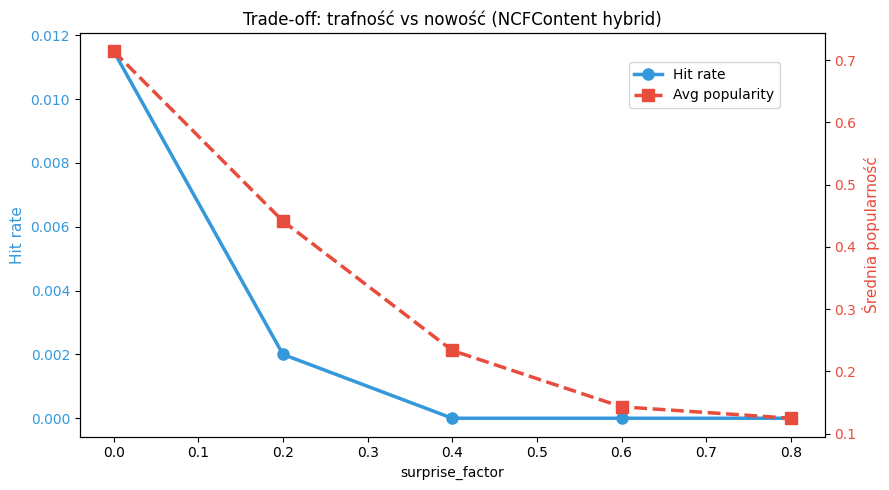

In [20]:
def evaluate_serendipity_offline(model_ncf, model_xgb, df_all,
                                  user2idx, wine2idx, device,
                                  content_dict, feat_dim, zero_vec,
                                  surprise_factor=0.4, n_users=100, top_n=10):
    results = []
    test_users = df_all[df_all['UserID'].isin(
        df_all['UserID'].value_counts()[lambda x: x >= top_n].index
    )]['UserID'].unique()[:n_users]

    for user_id in test_users:
        if user_id not in user2idx:
            continue
        user_ratings = df_all[df_all['UserID'] == user_id]
        n_test  = max(1, int(len(user_ratings) * 0.2))
        hidden  = user_ratings.tail(n_test)
        visible = user_ratings.iloc[:-n_test]
        if len(visible) < 5:
            continue
        df_temp = df_all[~df_all.index.isin(hidden.index)]
        try:
            recs = serendipity_recommendations(
                user_id, model_ncf, model_xgb, df_temp,
                user2idx, wine2idx, device,
                content_dict, feat_dim, zero_vec,
                top_n=top_n, n_candidates=1000,
                surprise_factor=surprise_factor,
            )
        except Exception:
            continue
        hidden_wines = set(hidden['WineID'])
        hits         = hidden_wines & set(recs['WineID'])
        hit_ratings  = hidden[hidden['WineID'].isin(hits)]['Rating']
        results.append({
            'user_id':        user_id,
            'hits':           len(hits),
            'good_hits':      (hit_ratings >= 4).sum(),
            'hit_rate':       len(hits) / top_n,
            'avg_popularity': recs['Popularity'].mean(),
        })
    return pd.DataFrame(results)


rows = []
for sf in [0.0, 0.2, 0.4, 0.6, 0.8]:
    df_eval = evaluate_serendipity_offline(
        model_ncf, model_xgb_hyb, df,
        user2idx, wine2idx, device,
        wine_content_dict, wine_feat_dim, zero_vec,
        surprise_factor=sf, n_users=200, top_n=10,
    )
    rows.append({
        'surprise_factor': sf,
        'avg_hit_rate':    round(df_eval['hit_rate'].mean(),      4),
        'avg_good_hits':   round(df_eval['good_hits'].mean(),     4),
        'avg_popularity':  round(df_eval['avg_popularity'].mean(), 4),
    })

serendipity_summary = pd.DataFrame(rows)
display(serendipity_summary)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(serendipity_summary['surprise_factor'], serendipity_summary['avg_hit_rate'],
         'o-', color='#3498db', linewidth=2.5, markersize=8, label='Hit rate')
ax1.set_ylabel('Hit rate', color='#3498db', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.set_xlabel('surprise_factor')
ax2 = ax1.twinx()
ax2.plot(serendipity_summary['surprise_factor'], serendipity_summary['avg_popularity'],
         's--', color='#e74c3c', linewidth=2.5, markersize=8, label='Avg popularity')
ax2.set_ylabel('Średnia popularność', color='#e74c3c', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#e74c3c')
plt.title('Trade-off: trafność vs nowość (NCFContent hybrid)')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()